# Bibliotecas

In [4]:
import os
import urllib.request
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import ssl

# Carregando dicionário PT-BR

In [9]:
contexto_ssl = ssl._create_unverified_context()

url_dicionario = "https://raw.githubusercontent.com/pythonprobr/palavras/master/palavras.txt"
response = urllib.request.urlopen(url_dicionario, context=contexto_ssl)
dicionario_pt = set(word.strip().lower() for word in response.read().decode('latin-1').splitlines())

# Lendo os textos do dataset aTribuna21

In [11]:
word_counts = Counter()
base_dir = "aTribuna21" # Nome da pasta que utilizei
classes_file = os.path.join(base_dir, "classes.txt")

# Lê as pastas a partir do classes.txt
with open(classes_file, 'r', encoding='latin-1') as f:
    pastas = [linha.strip() for linha in f if linha.strip()]

for pasta in pastas:
    caminho_pasta = os.path.join(base_dir, pasta)
    if not os.path.exists(caminho_pasta):
        continue
    
    for arquivo in os.listdir(caminho_pasta):
        if arquivo.endswith(".txt"):
            caminho_arquivo = os.path.join(caminho_pasta, arquivo)
            with open(caminho_arquivo, 'r', encoding='latin-1') as text_file:
                conteudo = text_file.read()
                # Separa por espaços em branco conforme solicitado e converte para minúsculas
                palavras = conteudo.lower().split()
                
                # Filtra mantendo apenas termos que existem no dicionário
                palavras_validas = [p for p in palavras if p in dicionario_pt]
                word_counts.update(palavras_validas)

# Modelagem segundo a Lei de Zipf

In [12]:
# Ordena as frequências reais (do termo mais frequente para o menos frequente)
frequencias_reais = sorted(list(word_counts.values()), reverse=True)

# Define o rank de cada palavra
ranks = np.arange(1, len(frequencias_reais) + 1)

# Frequência teórica segundo Zipf: F(n) = F(1) / n
freq_maxima = frequencias_reais[0] if frequencias_reais else 0
frequencias_teoricas = freq_maxima / ranks

# Gráficos

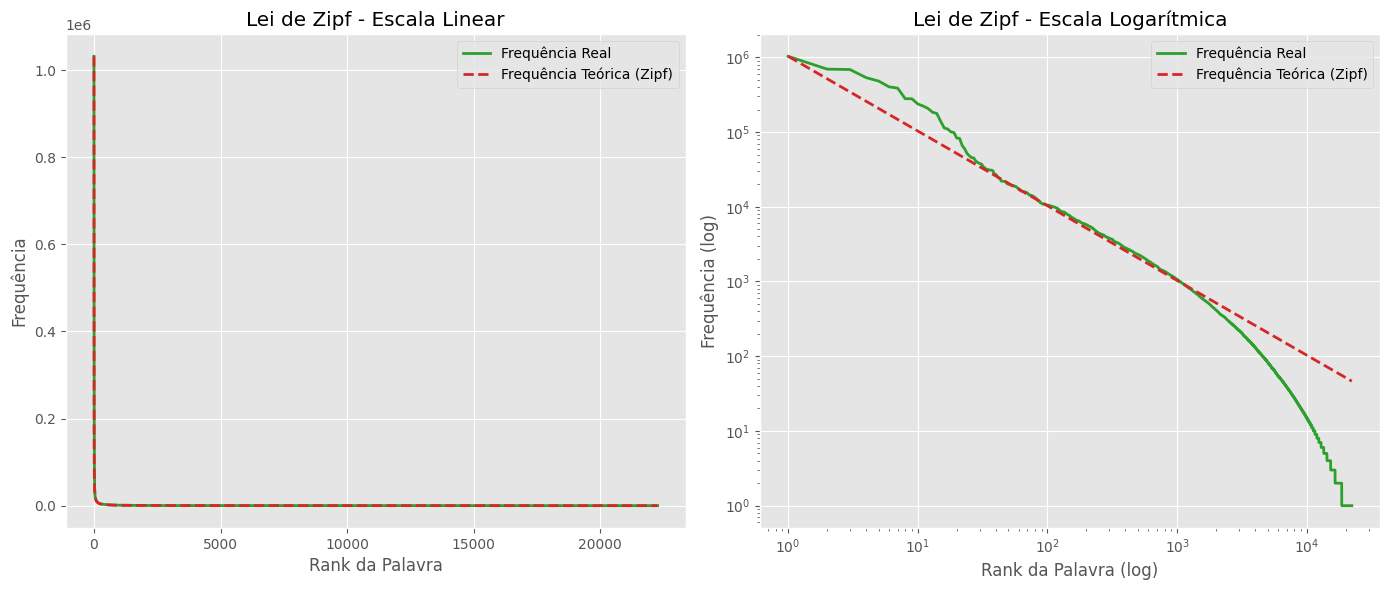

In [13]:
# Gráficos do Appsilon Team (Linear e Log-Log)
plt.style.use('ggplot') # Emula o visual do ggplot2 no R usado pela Appsilon
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Escala Linear
ax1.plot(ranks, frequencias_reais, label='Frequência Real', color='#2ca02c', linewidth=2)
ax1.plot(ranks, frequencias_teoricas, label='Frequência Teórica (Zipf)', color='#d62728', linestyle='--', linewidth=2)
ax1.set_title('Lei de Zipf - Escala Linear')
ax1.set_xlabel('Rank da Palavra')
ax1.set_ylabel('Frequência')
ax1.legend()

# Gráfico 2: Escala Logarítmica (Para visualizar a cauda longa)
ax2.plot(ranks, frequencias_reais, label='Frequência Real', color='#2ca02c', linewidth=2)
ax2.plot(ranks, frequencias_teoricas, label='Frequência Teórica (Zipf)', color='#d62728', linestyle='--', linewidth=2)
ax2.set_title('Lei de Zipf - Escala Logarítmica')
ax2.set_xlabel('Rank da Palavra (log)')
ax2.set_ylabel('Frequência (log)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()

Os gráficos refletem exatamente o comportamento real de textos linguísticos quando submetidos à Lei de Zipf o gráfico em escalar linear deixa evidente o comportamento de que poucas palavras possuem frequências muito grandes, enquanto a maioria forma uma longa cauda de palavras raras.

Já o gráfico de escala log-log revela a relação de potência da Lei de Zipf em formato de reta. A frequência real acompanha a tendência teórica central, apresentando apenas os desvios naturais nos extremos: nas palavras extremamente comuns (no topo) e na queda abrupta das palavras muito raras (no fim da cauda).